<a href="https://colab.research.google.com/github/sadhika-tech/deep-learning-lab/blob/main/Lab%203/convolutional_neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from keras.utils import to_categorical
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Dropout
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.utils import plot_model
import math

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15
})

In [ ]:
(X_train,y_train),(X_test,y_test)=cifar10.load_data()
class_names=['Airplane','Automobile','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2521s 15us/step


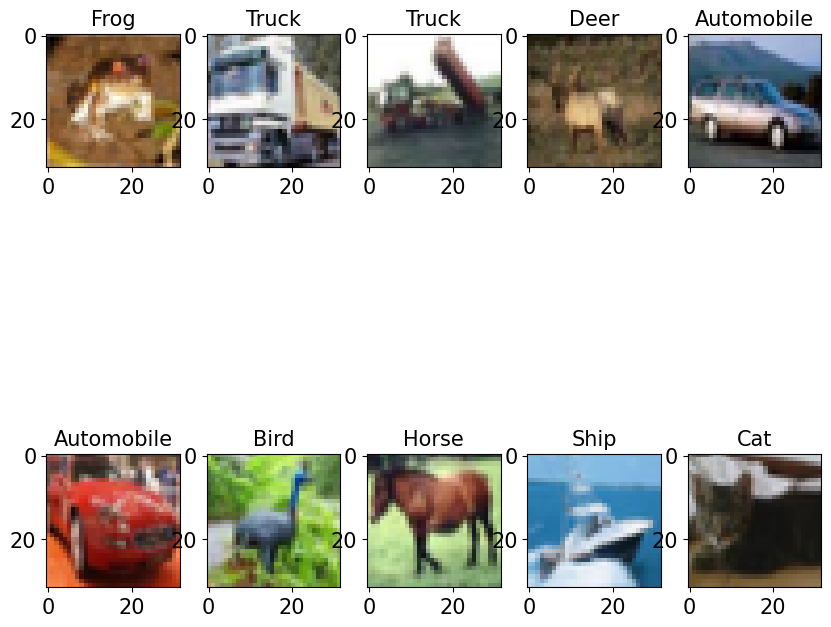

In [44]:
plt.figure(figsize=(10,10))

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_train[i])
  plt.title(class_names[y_train[i][0]])

plt.savefig("sample_images.png",dpi=600)
plt.show()


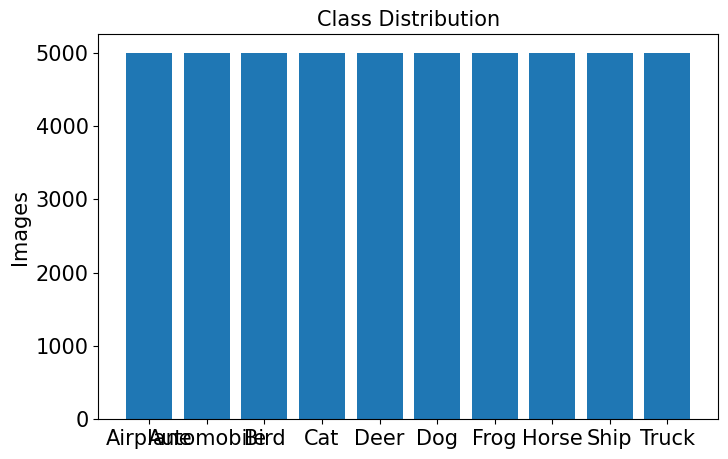

In [45]:
unique,counts=np.unique(y_train,return_counts=True)
plt.figure(figsize=(8,5))
plt.bar(class_names, counts)
plt.ylabel("Images")
plt.title("Class Distribution")
plt.savefig("class_distribution.png",dpi=600)
plt.show()

In [ ]:


X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

y_train_cat=to_categorical(y_train,10)
y_test_cat=to_categorical(y_test,10)

print("Training images: ",X_train.shape)
print("Testing images: ",X_test.shape)

Training images:  (50000, 32, 32, 3)
Testing images:  (10000, 32, 32, 3)


In [ ]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(128,(3,3),activation='relu',padding='same'))

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))


In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,242 (4.36 MB)

 Trainable params: 1,143,242 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist=model.fit(X_train,y_train_cat,epochs=20,batch_size=64,validation_split=0.2,verbose=1)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 96ms/step - accuracy: 0.3702 - loss: 1.7123 - val_accuracy: 0.5149 - val_loss: 1.3446
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.5140 - loss: 1.3534 - val_accuracy: 0.6090 - val_loss: 1.1194
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.5843 - loss: 1.1716 - val_accuracy: 0.6310 - val_loss: 1.0334
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.6314 - loss: 1.0456 - val_accuracy: 0.6767 - val_loss: 0.9075
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.6675 - loss: 0.9482 - val_accuracy: 0.6958 - val_loss: 0.8846
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - accuracy: 0.6949 - loss: 0.8746 - val_accuracy: 0.7124 - val_loss: 0.8344
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 106ms/step - accuracy: 0.7242 - loss: 0.7974 - val_accuracy: 0.7264 - val_loss: 0.7973
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.7431 - loss: 0.7337

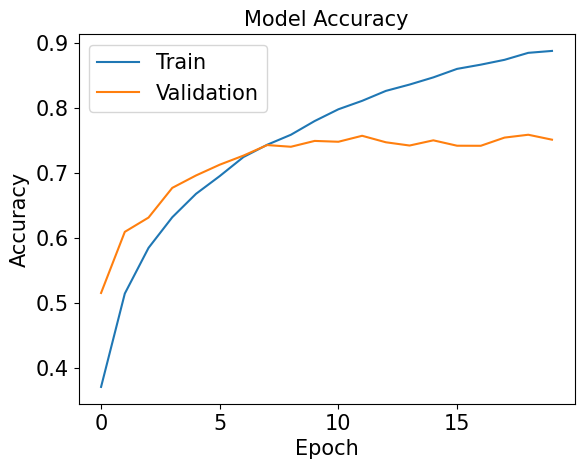

In [46]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.savefig("model_accuracy.png",dpi=600)
plt.show()

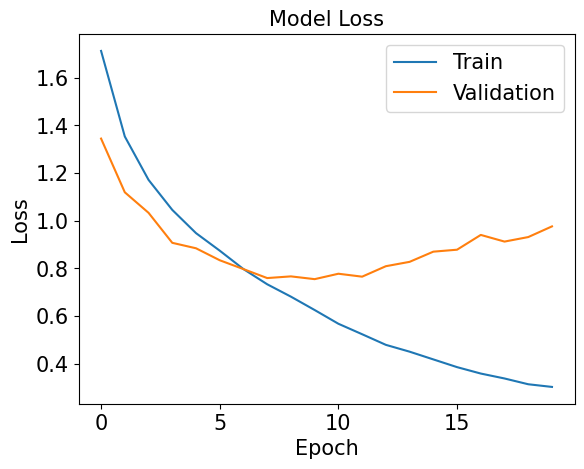

In [47]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.savefig("model_loss.png",dpi=600)
plt.show()

In [ ]:
loss,accuracy=model.evaluate(X_test,y_test_cat)
print("Test Loss: ",loss)
print("Test Accuracy: ",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7434 - loss: 1.0162
Test Loss:  1.01621675491333
Test Accuracy:  0.743399977684021


In [ ]:
pred=model.predict(X_test)
pred=np.argmax(pred,axis=1)
actual=y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


In [ ]:
print(classification_report(actual,pred,target_names=class_names))

              precision    recall  f1-score   support

    Airplane       0.72      0.83      0.77      1000
  Automobile       0.85      0.86      0.86      1000
        Bird       0.60      0.70      0.64      1000
         Cat       0.54      0.57      0.55      1000
        Deer       0.76      0.63      0.69      1000
         Dog       0.68      0.62      0.65      1000
        Frog       0.85      0.77      0.81      1000
       Horse       0.81      0.79      0.80      1000
        Ship       0.84      0.86      0.85      1000
       Truck       0.83      0.81      0.82      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



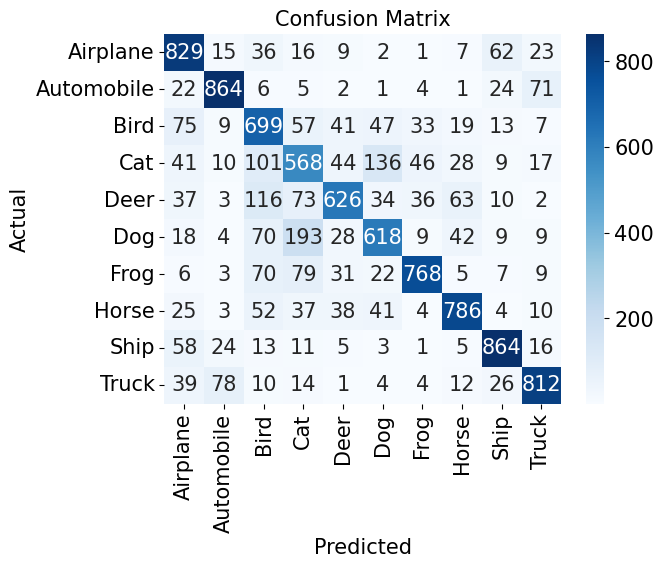

In [48]:
cm=confusion_matrix(actual,pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix.png",dpi=600)
plt.show()

In [ ]:
print("Total Trainable Parameters:")
print(model.count_params())

Total Trainable Parameters:
1143242


In [ ]:
# Build the model graph
model.build((None, 32, 32, 3))

# or simply call it once
model(X_test[:1])

<tf.Tensor: shape=(1, 10), dtype=float32, numpy=
array([[9.9228091e-06, 3.2503231e-05, 3.3822757e-06, 9.6817845e-01,
        1.3856780e-07, 3.1291068e-02, 1.5895168e-05, 5.0218587e-06,
        4.5741402e-04, 6.2075283e-06]], dtype=float32)>

In [ ]:
layer_outputs=[layer.output for layer in model.layers if "conv2d" in layer.name]

feature_model=Model(inputs=model.inputs,outputs=layer_outputs)

sample=X_test[0].reshape(1,32,32,3)

feature_maps=feature_model.predict(sample)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


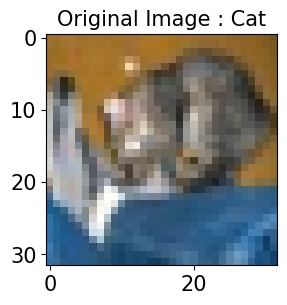

In [49]:
plt.figure(figsize=(3,3))
plt.imshow(X_test[0])
plt.title("Original Image : "+class_names[y_test[0][0]])
plt.savefig("original_image.png",dpi=600)
plt.show()

Conv Layer 1
Feature map shape: (1, 32, 32, 32)


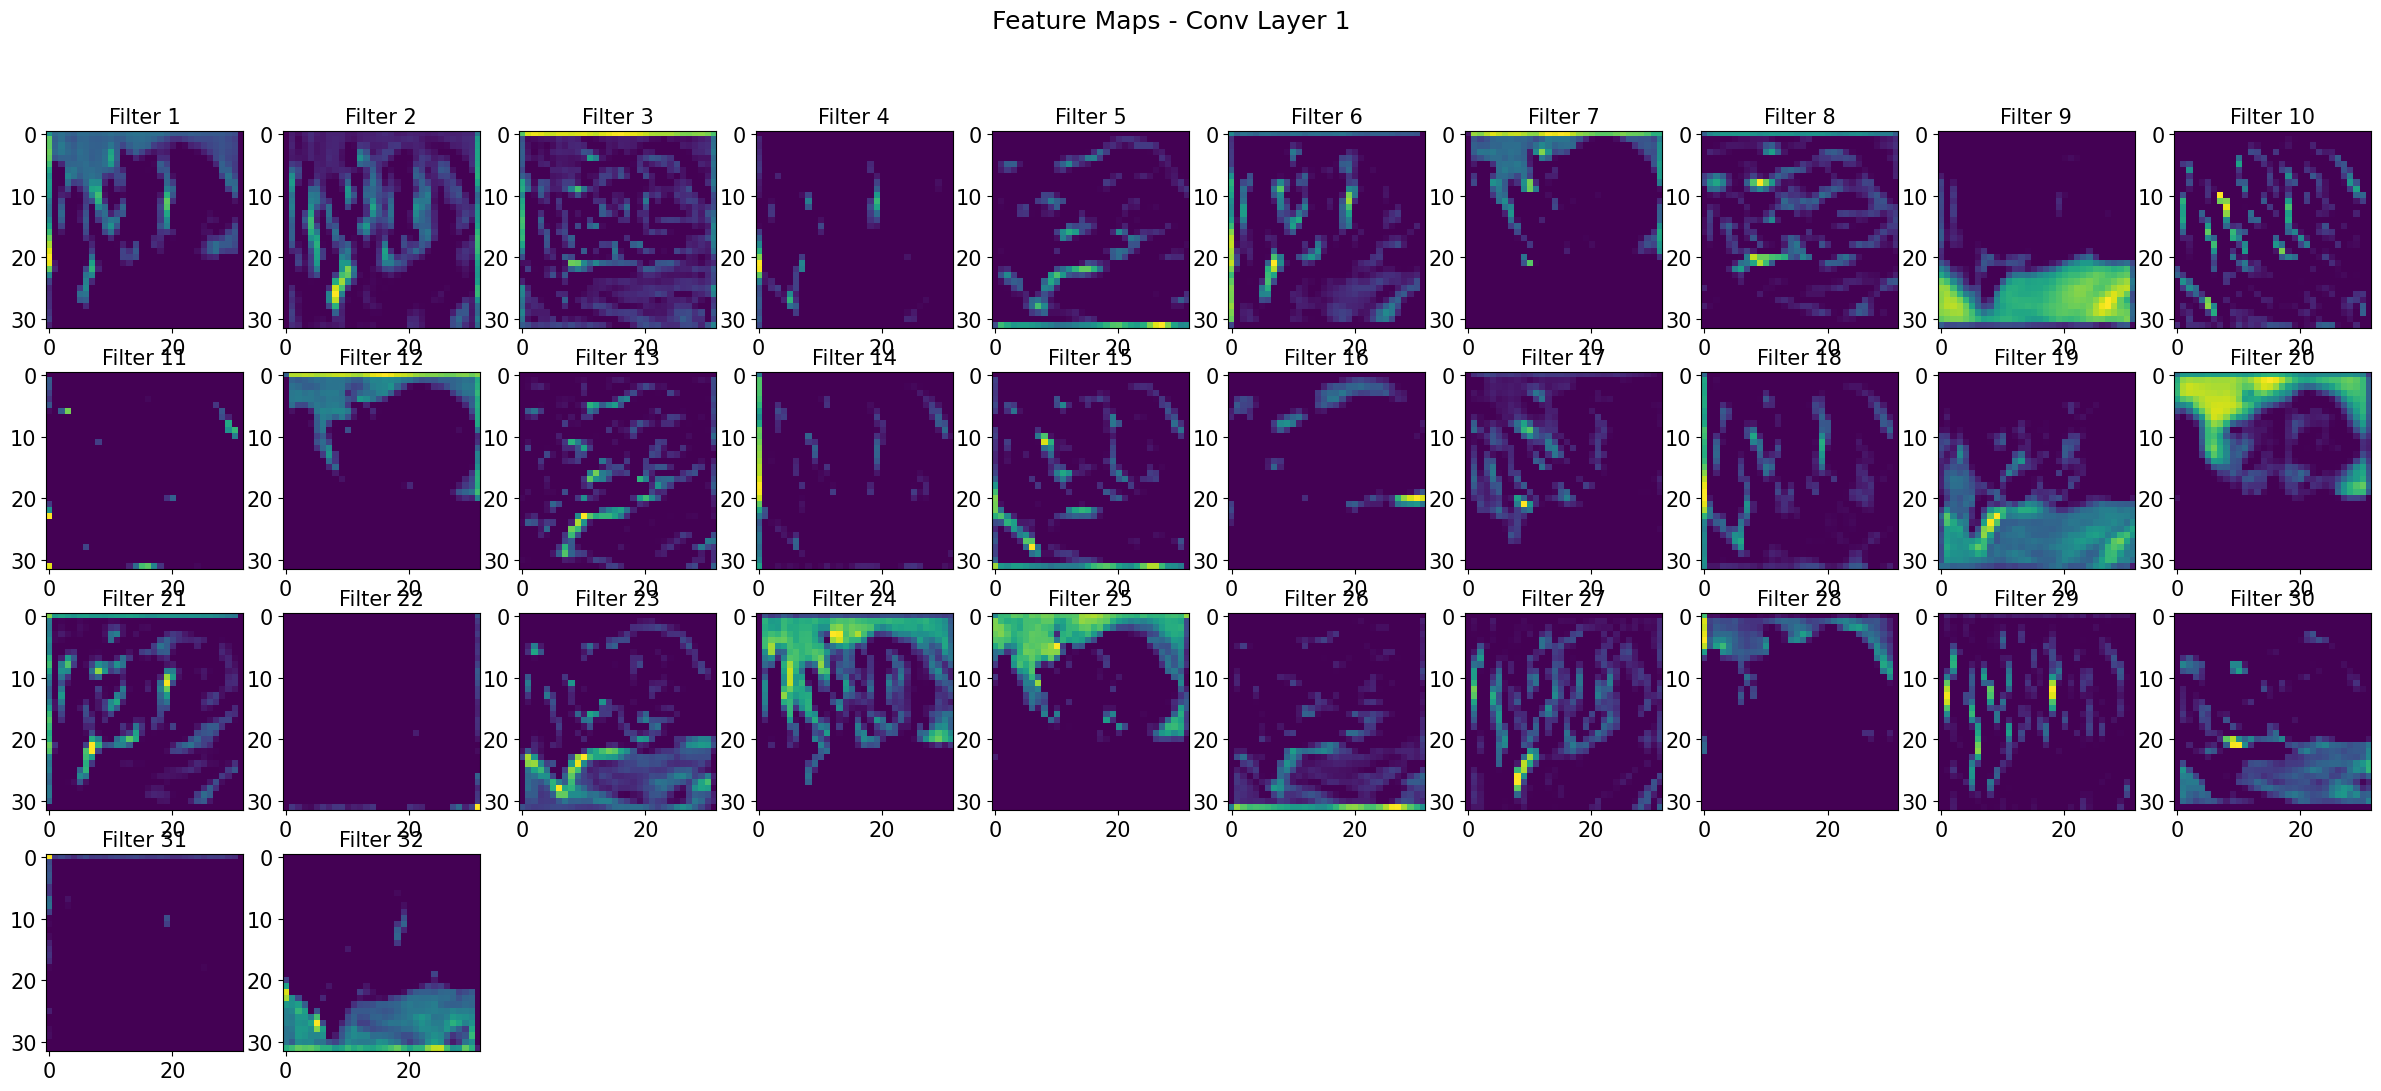

Conv Layer 2
Feature map shape: (1, 16, 16, 64)


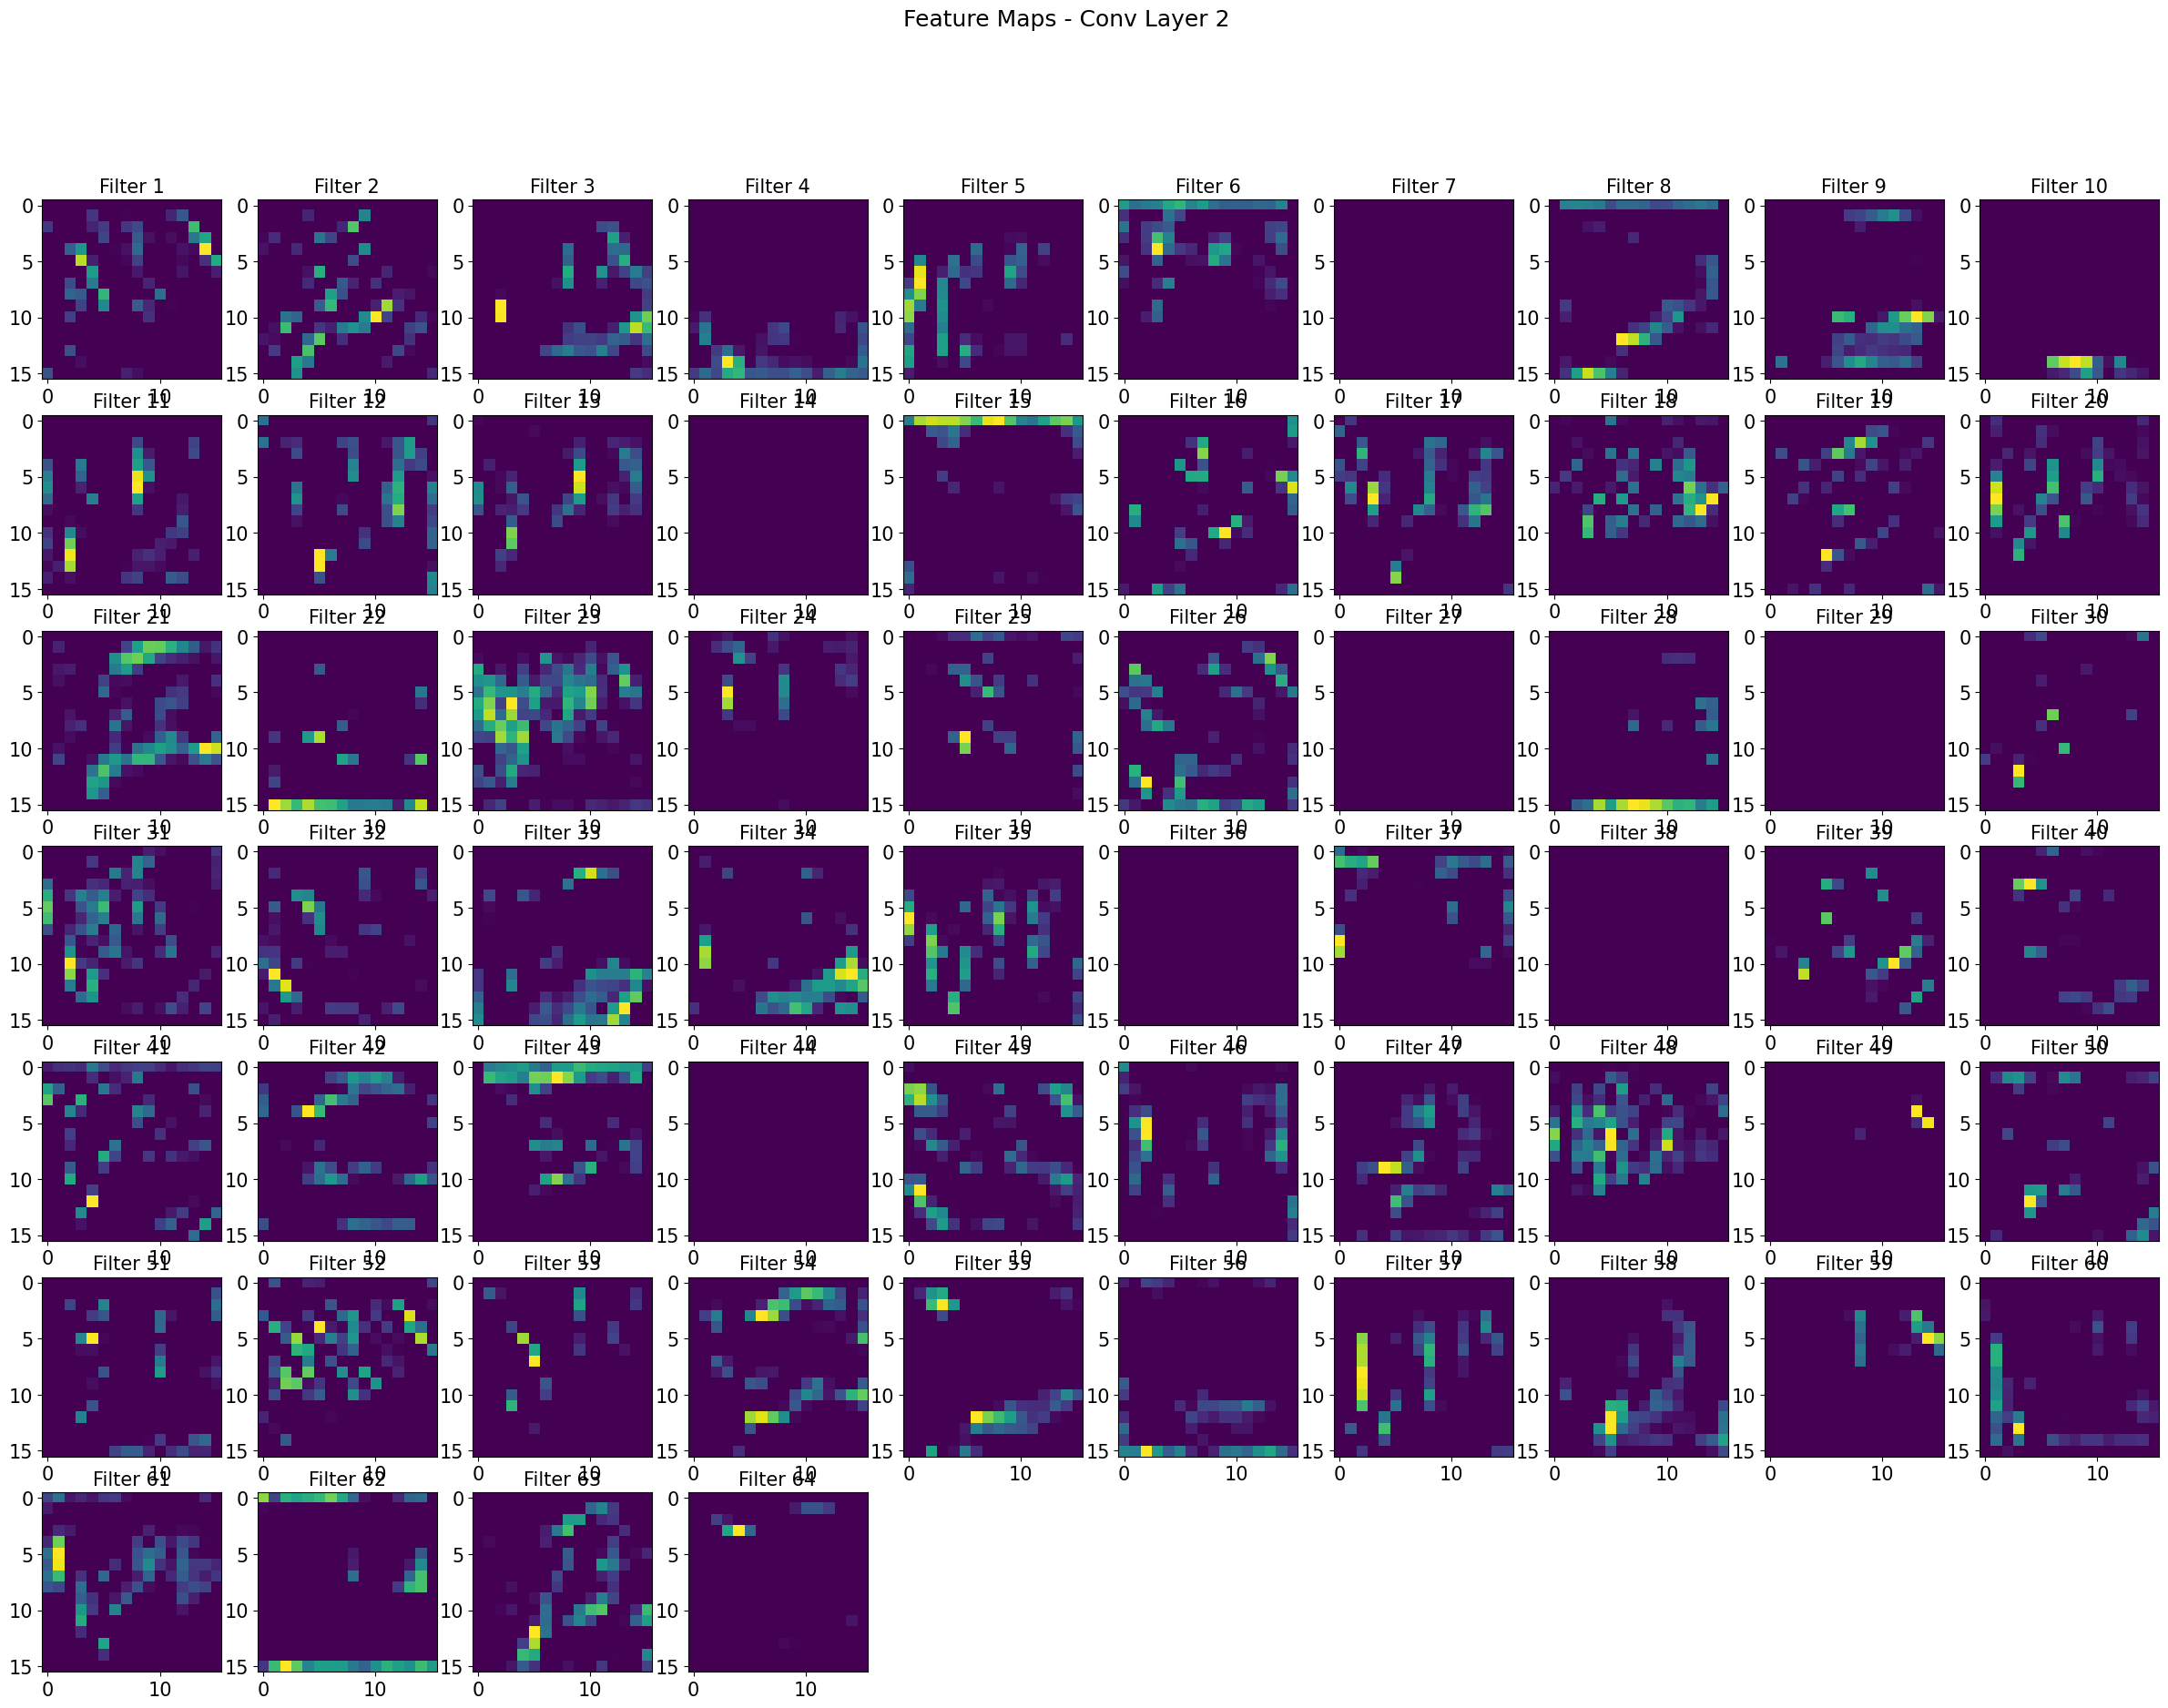

Conv Layer 3
Feature map shape: (1, 8, 8, 128)


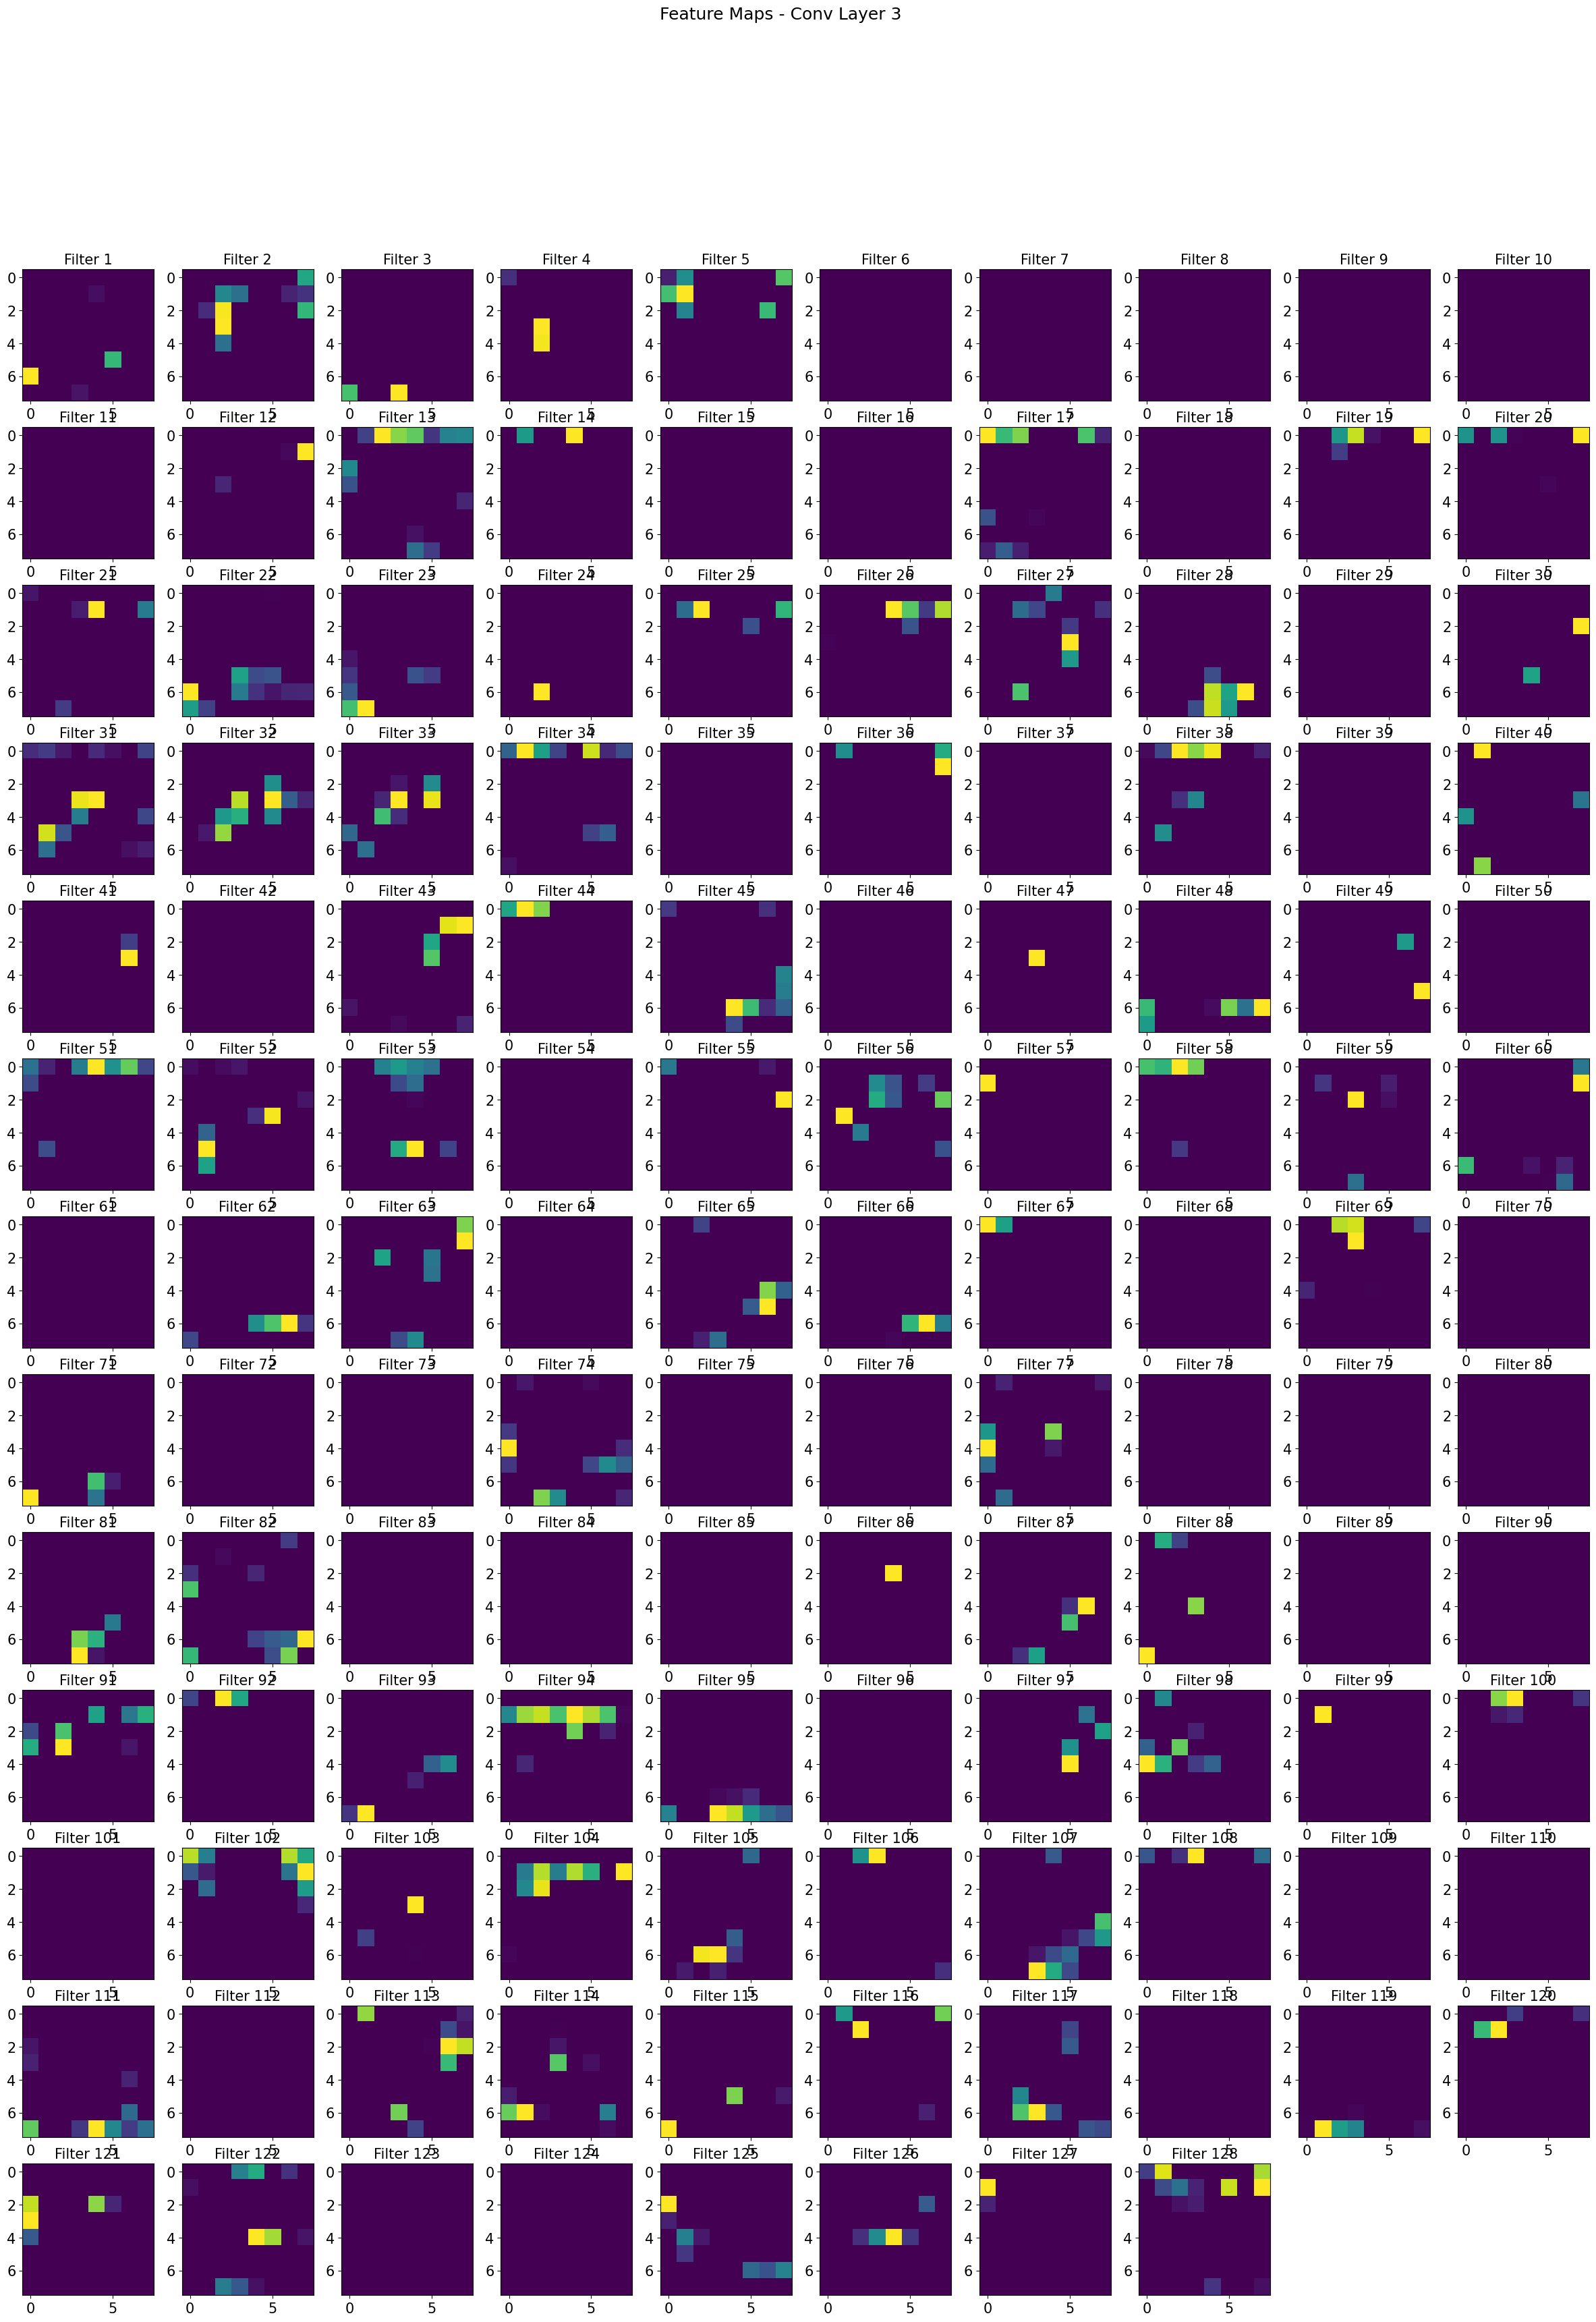

In [55]:
for layer_index, fmap in enumerate(feature_maps):

    print("Conv Layer", layer_index + 1)
    print("Feature map shape:", fmap.shape)
    n_features=fmap.shape[-1]
    cols = 10
    rows = math.ceil(n_features / cols)
    plt.figure(figsize=(30, rows*3))

    for i in range(n_features):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(fmap[0, :, :, i])
        plt.title("Filter " + str(i+1))

    plt.suptitle("Feature Maps - Conv Layer " + str(layer_index + 1))
    plt.savefig("feature_maps_conv_layer_"+str(layer_index+1)+".png",dpi=600)
    plt.show()

In [ ]:
f_conv=model.layers[0]
filters,biases=f_conv.get_weights()
print("Filter shape:", filters.shape)


Filter shape: (3, 3, 3, 32)


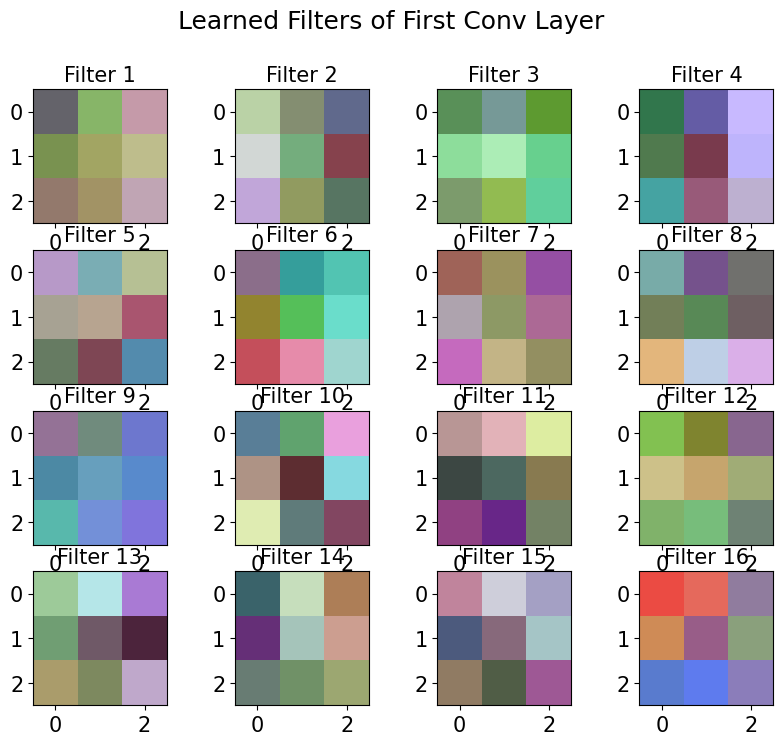

In [56]:
filters=(filters-filters.min())/(filters.max()-filters.min())
plt.figure(figsize=(10,8))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(filters[:,:,:,i])
    plt.title("Filter "+str(i+1))

plt.suptitle("Learned Filters of First Conv Layer")
plt.savefig("learned_filters.png",dpi=600)
plt.show()

In [ ]:
for layer in model.layers:
    if isinstance(layer, Conv2D):
        print("\nLayer:",layer.name)
        print("Kernel Size:",layer.kernel_size)
        print("Number of Filters:",layer.filters)
        print("Stride:",layer.strides)
        print("Padding:",layer.padding)
        print("Trainable Parameters:",layer.count_params())


Layer: conv2d
Kernel Size: (3, 3)
Number of Filters: 32
Stride: (1, 1)
Padding: same
Trainable Parameters: 896

Layer: conv2d_1
Kernel Size: (3, 3)
Number of Filters: 64
Stride: (1, 1)
Padding: same
Trainable Parameters: 18496

Layer: conv2d_2
Kernel Size: (3, 3)
Number of Filters: 128
Stride: (1, 1)
Padding: same
Trainable Parameters: 73856


In [ ]:
avg_model=Sequential()
avg_model.add(Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)))
avg_model.add(AveragePooling2D(pool_size=(2,2)))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
max_model=Sequential()
max_model.add(Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)))
max_model.add(MaxPooling2D(pool_size=(2,2)))

In [ ]:
img=X_test[0].reshape(1,32,32,3)
max_output =max_model.predict(img)
avg_output =avg_model.predict(img)
print("Max Pooling Output Shape:",max_output.shape)

print("Average Pooling Output Shape:",avg_output.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Max Pooling Output Shape: (1, 16, 16, 32)
Average Pooling Output Shape: (1, 16, 16, 32)


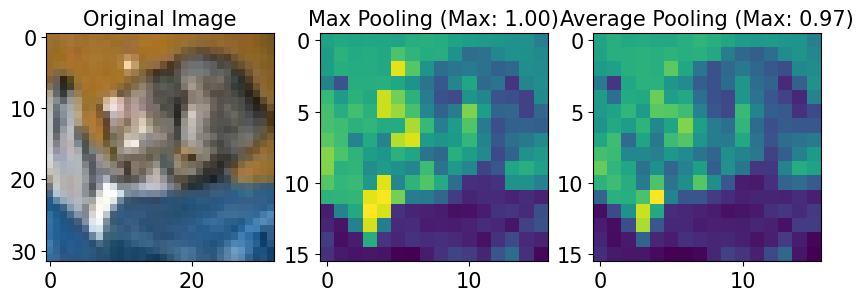

In [62]:
img=X_test[0:1]

max_pool =MaxPooling2D(pool_size=(2, 2))
avg_pool =AveragePooling2D(pool_size=(2, 2))

max=max_pool(img).numpy()
avg=avg_pool(img).numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img[0])
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(max[0, :, :, 0])
plt.title(f"Max Pooling (Max: {max[0,:,:,0].max():.2f})")

plt.subplot(1, 3, 3)
plt.imshow(avg[0, :, :, 0])
plt.title(f"Average Pooling (Max: {avg_output[0,:,:,0].max():.2f})")

plt.savefig("max_avg_pooling.png",dpi=600)
plt.show()